# Диагностика когорт перед DiD / событийная модель

## Назначение

Проверка состава когорт воздействия, доминирующих `change_type`, размеров выборок и поддержки событийного времени до основной DiD-оценки.

## Входные данные

Сырые CSV (`application_dataset.csv`, `hexagons_dataset.csv`); функция `build_analysis_panel()` из `last_mile.filter`.

## Результаты

Таблицы композиции когорт, диагностики малых когорт и событийного времени; графики в `figures/empirical/`; CSV в `outputs/cohort_diagnostics/`.

## Статус

Диагностический ноутбук, входит в пайплайн проверки выборки.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


## 0. Пути к проекту и данным

Ноутбук рассчитан на запуск из корня репозитория. При запуске из другой директории задаётся `PROJECT_ROOT`.


In [2]:
PROJECT_ROOT = Path.cwd()

# Если ноутбук лежит в notebooks/, удобно подняться на уровень выше.
if PROJECT_ROOT.name.lower() in {"notebooks", "notebook"}:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
APPLICATIONS_PATH = DATA_DIR / "application_dataset.csv"
HEXAGONS_PATH = DATA_DIR / "hexagons_dataset.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("APPLICATIONS_PATH exists:", APPLICATIONS_PATH.exists(), "->", APPLICATIONS_PATH)
print("HEXAGONS_PATH exists:", HEXAGONS_PATH.exists(), "->", HEXAGONS_PATH)

# На всякий случай добавляем корень проекта в sys.path, чтобы импортировался пакет last_mile.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


PROJECT_ROOT: <resolved relative to repository root>
APPLICATIONS_PATH exists: True -> <PROJECT_ROOT>/…
HEXAGONS_PATH exists: True -> <PROJECT_ROOT>/…


## 1. Импорт пайплайна

Блок импорта поддерживает два исторически использовавшихся имени модуля:
`last_mile.data_pipeline` и `last_mile.filter`. Актуальная реализация находится
в `last_mile.filter`.


In [3]:
def _import_module_from_file(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Не удалось создать spec для {file_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

pipeline_module = None
pipeline_import_error = None

for module_name in ["last_mile.data_pipeline", "last_mile.filter"]:
    try:
        pipeline_module = __import__(module_name, fromlist=["*"])
        print(f"Импортирован модуль: {module_name}")
        break
    except Exception as e:
        pipeline_import_error = e

if pipeline_module is None:
    candidate_files = [
        PROJECT_ROOT / "last_mile" / "data_pipeline.py",
        PROJECT_ROOT / "last_mile" / "filter.py",
        PROJECT_ROOT / "data_pipeline.py",
        PROJECT_ROOT / "filter.py",
    ]
    for fp in candidate_files:
        if fp.exists():
            pipeline_module = _import_module_from_file("pipeline_module", fp)
            print(f"Импортирован файл напрямую: {fp}")
            break

if pipeline_module is None:
    raise ImportError(
        "Не удалось импортировать pipeline. Проверь, что файл лежит в last_mile/data_pipeline.py "
        "или last_mile/filter.py, либо скорректировать блок импорта. Последняя ошибка: "
        f"{pipeline_import_error}"
    )

build_analysis_panel = pipeline_module.build_analysis_panel
CORE_CHANGE_TYPES = list(pipeline_module.CORE_CHANGE_TYPES)
EXCLUDED_COHORTS = getattr(pipeline_module, "EXCLUDED_COHORTS", {pd.Timestamp("2022-10-19")})

print("CORE_CHANGE_TYPES:", CORE_CHANGE_TYPES)
print("EXCLUDED_COHORTS:", sorted(str(pd.Timestamp(c).date()) for c in EXCLUDED_COHORTS))


Импортирован модуль: last_mile.filter
CORE_CHANGE_TYPES: ['region_only', 'workmode_only', 'region_and_workmode']
EXCLUDED_COHORTS: ['2022-10-19']


## 2. Функции диагностики когорт

Используется модуль `last_mile.cohort_diagnostics`. Резервная реализация здесь не дублируется: если файл диагностики есть в репозитории, лучше использовать единую версию логики, а не дублировать её в ноутбуке.


In [4]:
from last_mile.cohort_diagnostics import (
    cohort_composition_report,
    print_cohort_composition_report,
    EXCLUDED_COHORT_FOR_CONVERSION,
    MIN_HEXAGONS_THRESHOLD,
)

print("Используется last_mile.cohort_diagnostics")
print("EXCLUDED_COHORT_FOR_CONVERSION:", EXCLUDED_COHORT_FOR_CONVERSION.date())
print("MIN_HEXAGONS_THRESHOLD:", MIN_HEXAGONS_THRESHOLD)


Используется last_mile.cohort_diagnostics
EXCLUDED_COHORT_FOR_CONVERSION: 2022-07-27
MIN_HEXAGONS_THRESHOLD: 5


## 3. Построение аналитической панели

Здесь используется тот же пайплайн, что и для основной оценки. Это важно: диагностика когорт должна считаться на той же выборке, на которой потом запускается DiD, иначе размеры групп будут расходиться.


In [5]:
MIN_ORDERS_PER_HEX = 5

result = build_analysis_panel(
    applications_path=APPLICATIONS_PATH,
    hexagons_path=HEXAGONS_PATH,
    min_orders_per_hex=MIN_ORDERS_PER_HEX,
)

panel = result["panel"].copy()
treated_orders = result["treated_orders"].copy()
control_orders = result["control_orders"].copy()
cohort_map = result["cohort_map"].copy()

# Для диагностик на уровне гексагонов безопаснее использовать одну строку на hex.
# Если cohort_map уже уникален, эта операция ничего не меняет.
cohort_map_unique = cohort_map.drop_duplicates(subset=["hex"]).copy()

for df in [panel, treated_orders, control_orders, cohort_map, cohort_map_unique]:
    if "cohort" in df.columns:
        df["cohort"] = pd.to_datetime(df["cohort"])
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

print("panel:", panel.shape)
print("treated_orders:", treated_orders.shape)
print("control_orders:", control_orders.shape)
print("cohort_map:", cohort_map.shape)
print("cohort_map_unique:", cohort_map_unique.shape)

if len(cohort_map) != len(cohort_map_unique):
    print(
        "[WARN] cohort_map содержит неуникальные строки по hex. "
        "Для cohort_composition_report будет использован cohort_map_unique."
    )


[INFO] resolve_hexagon_treatments: исключено 15832 multi-treatment гексагонов; сохранено 3613240 single/never.


[INFO] multi-treatment diagnostics: <PROJECT_ROOT>/…


[INFO] attach_hex_metadata: отброшено 109 заявок из гексагонов, не представленных в hexagons_dataset.
[INFO] exclude_cohorts: исключено 683082 заявок из когорт ['2022-10-19'].


[INFO] build_analysis_panel: после порогового фильтра (≥5 заявок) осталось 13255 уникальных гексагонов.



СВОДКА АНАЛИТИЧЕСКОЙ ПАНЕЛИ
  Период:              2022-04-01 - 2022-10-18
  Наблюдений (hex×day):   302,398
  Гексагонов всего:        13,255
  - трактуемых:             9,327
  - never-treated:          3,928

  Когорты (включённые):
    2022-07-27  →  437 гексагонов
    2022-08-12  →  1358 гексагонов
    2022-08-19  →  2723 гексагонов
    2022-09-22  →  4809 гексагонов

  Исключённые когорты: ['2022-10-19']



panel: (302398, 13)
treated_orders: (781369, 18)
control_orders: (323125, 18)
cohort_map: (3613240, 5)
cohort_map_unique: (3613240, 5)


## 4. Базовая сводка панели


In [6]:
def _safe_date(x):
    if pd.isna(x):
        return None
    return pd.Timestamp(x).date()

basic_summary = pd.DataFrame({
    "metric": [
        "period_start",
        "period_end",
        "n_panel_observations_hex_day",
        "n_hex_total_in_panel",
        "n_treated_hex_in_panel",
        "n_control_hex_in_panel",
        "n_treated_orders",
        "n_control_orders",
        "min_orders_per_hex_filter",
    ],
    "value": [
        _safe_date(panel["date"].min()) if "date" in panel else None,
        _safe_date(panel["date"].max()) if "date" in panel else None,
        len(panel),
        panel["hex"].nunique(),
        panel.loc[panel["is_treated"], "hex"].nunique(),
        panel.loc[~panel["is_treated"], "hex"].nunique(),
        len(treated_orders),
        len(control_orders),
        MIN_ORDERS_PER_HEX,
    ]
})

display(basic_summary)


                         metric       value
0                  period_start  2022-04-01
1                    period_end  2022-10-18
2  n_panel_observations_hex_day      302398
3          n_hex_total_in_panel       13255
4        n_treated_hex_in_panel        9327
5        n_control_hex_in_panel        3928
6              n_treated_orders      781369
7              n_control_orders      323125
8     min_orders_per_hex_filter           5

### Вывод 1. Размер аналитической панели

После построения аналитической панели период исследования составляет `2022-04-01 — 2022-10-18`. Единицей наблюдения является пара `гексагон × день`, что соответствует дальнейшей TWFE DiD-спецификации на панельных данных.

После исключения когорты `2022-10-19`, для которой отсутствует достаточный постпериод, и применения фильтра `min_orders_per_hex = 5` в панели осталось `302 403` наблюдения уровня `hex × day`. В аналитическую выборку вошло `13 256` уникальных гексагонов: `9 328` гексагонов воздействия и `3 928` гексагонов постоянной контрольной группы. На уровне заявок в группе воздействия осталось `781 380` наблюдений, в контрольной группе — `323 125`.

С точки зрения общего размера выборка выглядит достаточной для DiD: есть крупная группа воздействия, крупная контрольная группа и несколько когорт воздействия. Основной риск связан не с общим количеством наблюдений, а с тем, что группа воздействия неоднородна по типам изменений логистической конфигурации. Поэтому дальше требуется диагностика состава когорт по `change_type`.


## 5. Полная композиция когорт: все `change_type`

Эта таблица отвечает на вопрос: что вошло в группу воздействия до методологических исключений. Здесь важно увидеть долю `other`, `opened`, `closed` и прочих типов, которые нельзя автоматически смешивать с основными изменениями региона/режима.


In [7]:
report = cohort_composition_report(
    cohort_map=cohort_map_unique,
    treated_orders=treated_orders,
)

print_cohort_composition_report(report)


ПОЛНАЯ КОМПОЗИЦИЯ КОГОРТ (все change_type, n_hexagons)
change_type  closed  never_active  opened  other  region_and_workmode  region_only  workmode_only
cohort                                                                                           
2022-07-27        2            47      62    193                   10            0            123
2022-08-12       42             4      77    608                  370          189             68
2022-08-19       51           140     185   1190                  350            1            806
2022-09-22      279            19      23   1895                 1502          340            751

КОМПОЗИЦИЯ ДЛЯ sch_flg (CORE_CHANGE_TYPES; 2022-07-27 сохранена)
change_type  region_and_workmode  region_only  workmode_only
cohort                                                      
2022-07-27                    10            0            123
2022-08-12                   370          189             68
2022-08-19                   350            1  

In [8]:
def with_total(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy().sort_index()
    out["TOTAL"] = out.sum(axis=1)
    return out


def row_shares(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    denom = df.sum(axis=1).replace(0, np.nan)
    return (df.div(denom, axis=0) * 100).round(1).sort_index()

composition_full_n = with_total(report["composition_full"])
composition_full_share = row_shares(report["composition_full"])

print("n_hexagons:")
display(composition_full_n)

print("row shares, %:")
display(composition_full_share)


n_hexagons:


change_type  closed  never_active  opened  other  region_and_workmode  region_only  workmode_only  TOTAL
cohort                                                                                                  
2022-07-27        2            47      62    193                   10            0            123    437
2022-08-12       42             4      77    608                  370          189             68   1358
2022-08-19       51           140     185   1190                  350            1            806   2723
2022-09-22      279            19      23   1895                 1502          340            751   4809

row shares, %:


change_type  closed  never_active  opened  other  region_and_workmode  region_only  workmode_only
cohort                                                                                           
2022-07-27    0.500        10.800  14.200 44.200                2.300        0.000         28.100
2022-08-12    3.100         0.300   5.700 44.800               27.200       13.900          5.000
2022-08-19    1.900         5.100   6.800 43.700               12.900        0.000         29.600
2022-09-22    5.800         0.400   0.500 39.400               31.200        7.100         15.600

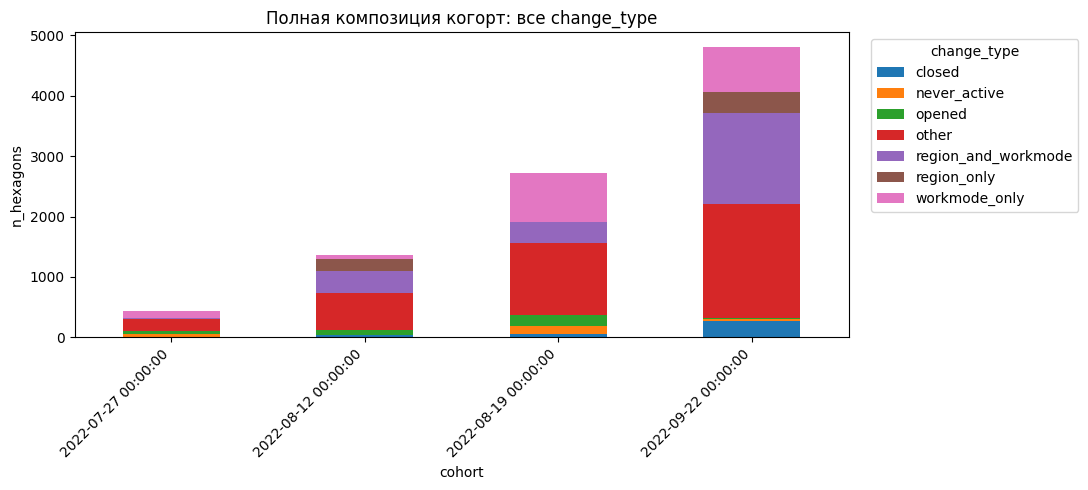

In [9]:
def plot_stacked_bar(df: pd.DataFrame, title: str, ylabel: str = "n_hexagons"):
    if df is None or df.empty:
        print(f"Нет данных для графика: {title}")
        return
    ax = df.sort_index().plot(kind="bar", stacked=True, figsize=(11, 5))
    ax.set_title(title)
    ax.set_xlabel("cohort")
    ax.set_ylabel(ylabel)
    ax.legend(title="change_type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_stacked_bar(report["composition_full"], "Полная композиция когорт: все change_type")


### Вывод 2. Полная группа воздействия

Полная группа воздействия неоднородна по типам изменений логистической конфигурации. Из `9 328` гексагонов воздействия только `4 510` относятся к CORE-изменениям, то есть к содержательно интерпретируемым изменениям активной зоны: `region_only`, `workmode_only`, `region_and_workmode`. Остальные `4 818` гексагонов относятся к non-CORE типам: `other`, `opened`, `closed`, `never_active`.

Наиболее проблемная категория — `other`: она составляет значительную часть каждой когорты и в сумме включает `3 886` гексагонов. По когортам её доля находится примерно на уровне `39–45%`: `44.2%` для `2022-07-27`, `44.8%` для `2022-08-12`, `43.7%` для `2022-08-19` и `39.4%` для `2022-09-22`. Это означает, что простое использование индикатора `is_treated` смешивает содержательно разные случаи и не даёт чистой интерпретации эффекта изменения региона или режима работы.

Также в полной группе воздействия присутствуют `opened` и `closed`. Эти типы структурно отличаются от обычной смены конфигурации активного гексагона, потому что в них меняется сам факт доступности зоны доставки. Поэтому их нельзя интерпретировать так же, как `region_only`, `workmode_only` или `region_and_workmode`.

Следовательно, полная группа воздействия полезна как диагностическая таблица, но не должна напрямую использоваться как единая группа воздействия в основной причинной интерпретации. Главный риск полной группы воздействия — смешение разных механизмов воздействия: смены региона, смены режима работы, открытия/закрытия зон и прочих нестандартных изменений.


## 6. Композиция для `sch_flg`: только CORE-изменения

Для `sch_flg` оставляем только `CORE_CHANGE_TYPES`: `region_only`, `workmode_only`, `region_and_workmode`. Когорта `2022-07-27` сохраняется, если она не нарушает предпосылку параллельных трендов именно для `sch_flg`.


n_hexagons, sch_flg sample:


change_type  region_and_workmode  region_only  workmode_only  TOTAL
cohort                                                             
2022-07-27                    10            0            123    133
2022-08-12                   370          189             68    627
2022-08-19                   350            1            806   1157
2022-09-22                  1502          340            751   2593

row shares, %, sch_flg sample:


change_type,region_and_workmode,region_only,workmode_only
cohort,,,
2022-07-27,7.500,0.000,92.500
2022-08-12,59.000,30.100,10.800
2022-08-19,30.300,0.100,69.700
2022-09-22,57.900,13.100,29.000


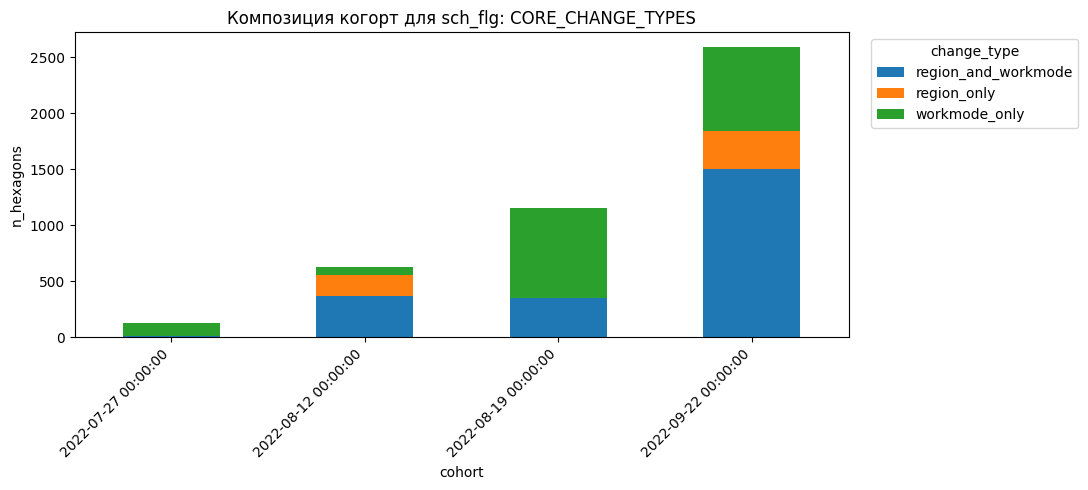

In [10]:
composition_sch_n = with_total(report["composition_sch"])
composition_sch_share = row_shares(report["composition_sch"])

print("n_hexagons, sch_flg sample:")
display(composition_sch_n)

print("row shares, %, sch_flg sample:")
display(composition_sch_share)

plot_stacked_bar(report["composition_sch"], "Композиция когорт для sch_flg: CORE_CHANGE_TYPES")


### Вывод 3. Выборка для `sch_flg`

Для анализа `sch_flg` используются только CORE-типы изменений: `region_only`, `workmode_only`, `region_and_workmode`. Это означает, что из группы воздействия исключаются структурно иные случаи вроде `opened`, `closed`, `never_active` и `other`, поскольку они не отражают обычную смену конфигурации уже активного гексагона.

В выборке для `sch_flg` остаются четыре когорты: `2022-07-27`, `2022-08-12`, `2022-08-19` и `2022-09-22`. Самая крупная когорта — `2022-09-22`, в ней `2 593` CORE-гексагона. Самая маленькая когорта — `2022-07-27`, в ней `133` CORE-гексагона. При этом формально малых когорт по заданному порогу `< 5` гексагонов нет.

Внутри когорт наблюдается выраженная композиционная гетерогенность. Когорта `2022-07-27` почти полностью состоит из `workmode_only`: `123` из `133` гексагонов, или `92.5%`. Когорта `2022-08-19` также преимущественно состоит из `workmode_only`: `806` из `1 157` гексагонов, или `69.7%`. В отличие от них, когорты `2022-08-12` и `2022-09-22` в основном представлены типом `region_and_workmode`: соответственно `59.0%` и `57.9%`.

Следовательно, при интерпретации результатов для `sch_flg` нельзя рассматривать различия между когортами только как различия во времени воздействия. Часть когортной гетерогенности может быть связана не с датой изменения, а с разным составом типов воздействия. Например, сравнение когорты `2022-08-19` с когортой `2022-09-22` частично является сравнением гексагонов со сменой режима работы против гексагонов с одновременной сменой региона и режима работы. Поэтому в дальнейшем анализе необходимо либо явно оговорить это ограничение, либо дополнительно оценивать эффекты раздельно по типам CORE-изменений.


## 7. Композиция для `success_flg` и `utlz_flg`

Для конверсионных исходов дополнительно исключается когорта `2022-07-27`, если ранее по ней было найдено нарушение предпосылки параллельных трендов. Поэтому размер группы воздействия для `success_flg / utlz_flg` должен быть меньше, чем для `sch_flg`.


n_hexagons, success_flg / utlz_flg sample:


change_type,region_and_workmode,region_only,workmode_only,TOTAL
cohort,,,,
2022-08-12,370,189,68,627
2022-08-19,350,1,806,1157
2022-09-22,1502,340,751,2593


row shares, %, success_flg / utlz_flg sample:


change_type,region_and_workmode,region_only,workmode_only
cohort,,,
2022-08-12,59.000,30.100,10.800
2022-08-19,30.300,0.100,69.700
2022-09-22,57.900,13.100,29.000


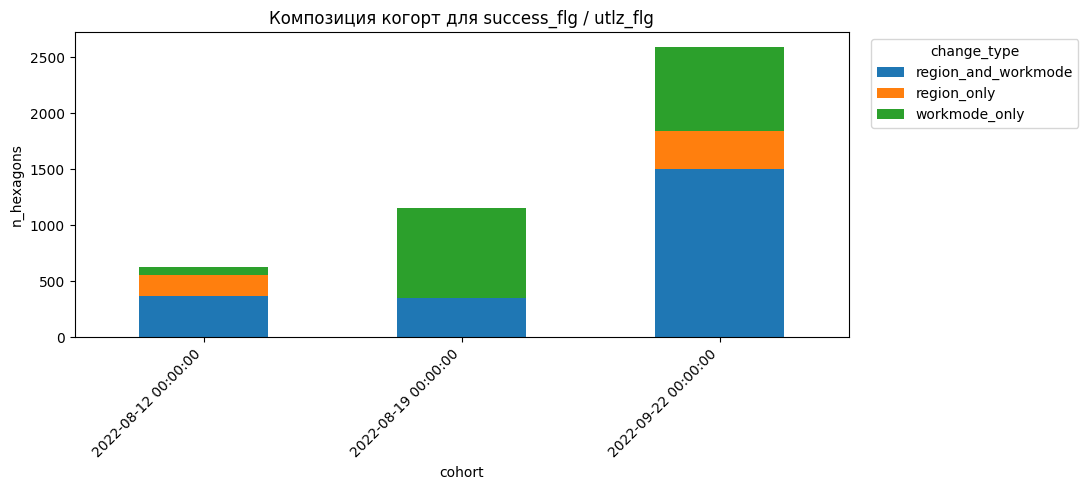

In [11]:
composition_conv_n = with_total(report["composition_conversion"])
composition_conv_share = row_shares(report["composition_conversion"])

print("n_hexagons, success_flg / utlz_flg sample:")
display(composition_conv_n)

print("row shares, %, success_flg / utlz_flg sample:")
display(composition_conv_share)

plot_stacked_bar(report["composition_conversion"], "Композиция когорт для success_flg / utlz_flg")


### Вывод 4. Выборка для `success_flg / utlz_flg`

Для анализа `success_flg` и `utlz_flg` используется более строгая выборка, чем для `sch_flg`. Из неё исключается когорта `2022-07-27`, поскольку ранее для этой когорты было выявлено нарушение предпосылки параллельных трендов для конверсионных исходов. Поэтому в выборке остаются только три когорты: `2022-08-12`, `2022-08-19` и `2022-09-22`.

После исключения когорты `2022-07-27` размер CORE-группы воздействия для `success_flg / utlz_flg` составляет `4 377` гексагонов. Это меньше, чем для `sch_flg`, где сохранялись все четыре когорты и было `4 510` CORE-гексагонов. Самая крупная когорта — `2022-09-22`, в ней `2 593` CORE-гексагона. Самая маленькая когорта — `2022-08-12`, в ней `627` CORE-гексагонов. Формально малых когорт по порогу `< 5` гексагонов нет.

Композиционная неоднородность сохраняется и после исключения `2022-07-27`. Когорта `2022-08-12` преимущественно состоит из `region_and_workmode`: `370` из `627` гексагонов, или `59.0%`; при этом значимую долю занимает `region_only` — `30.1%`. Когорта `2022-08-19` резко отличается по составу: `workmode_only` составляет `806` из `1 157` гексагонов, или `69.7%`, тогда как `region_only` почти отсутствует. Когорта `2022-09-22` снова в основном представлена `region_and_workmode`: `1 502` из `2 593` гексагонов, или `57.9%`, но также содержит заметную долю `workmode_only` — `29.0%`.

Следовательно, исключение проблемной когорты `2022-07-27` улучшает валидность выборки с точки зрения параллельных трендов для конверсионных исходов, но не устраняет композиционную гетерогенность. Оценки по `sch_flg` и по `success_flg / utlz_flg` считаются на не полностью одинаковых выборках воздействия, поэтому их нельзя напрямую сравнивать как результаты на одном и том же наборе когорт.


## 8. Доминирующий тип изменения внутри каждой когорты

Это ключевая проверка на композиционную гетерогенность. Если разные когорты состоят из разных типов воздействия, то staggered DiD может смешивать эффект времени воздействия с эффектом типа изменения.


In [12]:
def dominant_type_table(composition: pd.DataFrame) -> pd.DataFrame:
    if composition is None or composition.empty:
        return pd.DataFrame()
    c = composition.fillna(0).copy().sort_index()
    total = c.sum(axis=1)
    dominant_type = c.idxmax(axis=1)
    dominant_n = c.max(axis=1)
    dominant_share = (dominant_n / total.replace(0, np.nan)).round(3)

    def flag(x):
        if pd.isna(x):
            return "нет данных"
        if x >= 0.80:
            return "очень сильное доминирование"
        if x >= 0.60:
            return "заметное доминирование"
        return "смешанный состав"

    return pd.DataFrame({
        "n_hex_total": total.astype(int),
        "dominant_type": dominant_type,
        "dominant_n": dominant_n.astype(int),
        "dominant_share": dominant_share,
        "composition_flag": dominant_share.map(flag),
    })

print("Доминирование типов, sch_flg:")
dominant_sch = dominant_type_table(report["composition_sch"])
display(dominant_sch)

print("Доминирование типов, success_flg / utlz_flg:")
dominant_conv = dominant_type_table(report["composition_conversion"])
display(dominant_conv)


Доминирование типов, sch_flg:


            n_hex_total        dominant_type  dominant_n  dominant_share             composition_flag
cohort                                                                                               
2022-07-27          133        workmode_only         123           0.925  очень сильное доминирование
2022-08-12          627  region_and_workmode         370           0.590             смешанный состав
2022-08-19         1157        workmode_only         806           0.697       заметное доминирование
2022-09-22         2593  region_and_workmode        1502           0.579             смешанный состав

Доминирование типов, success_flg / utlz_flg:


,n_hex_total,dominant_type,dominant_n,dominant_share,composition_flag
cohort,,,,,
2022-08-12,627,region_and_workmode,370,0.590,смешанный состав
2022-08-19,1157,workmode_only,806,0.697,заметное доминирование
2022-09-22,2593,region_and_workmode,1502,0.579,смешанный состав


### Вывод 5. Композиционная гетерогенность когорт

Проверка доминирующего типа изменения показывает, что когорты существенно различаются по внутреннему составу `change_type`. Это означает, что когорты отличаются не только датой воздействия, но и типом логистического изменения.

Для `sch_flg` наиболее выраженное доминирование наблюдается в когорте `2022-07-27`: `workmode_only` составляет `123` из `133` CORE-гексагонов, то есть `92.5%`. Это почти однородная когорта, отражающая преимущественно изменение режима работы. Когорта `2022-08-19` также в основном состоит из `workmode_only`: `806` из `1 157` гексагонов, или `69.7%`, что указывает на заметное доминирование этого типа воздействия.

В отличие от них, когорты `2022-08-12` и `2022-09-22` имеют более смешанный состав. В обеих доминирует `region_and_workmode`, но его доля не является подавляющей: `59.0%` для `2022-08-12` и `57.9%` для `2022-09-22`. Это означает, что в этих когортах присутствует более существенная смесь разных типов CORE-изменений.

Для `success_flg` и `utlz_flg` когорта `2022-07-27` исключается, поэтому остаются три когорты: `2022-08-12`, `2022-08-19` и `2022-09-22`. Однако композиционная гетерогенность сохраняется: `2022-08-19` по-прежнему преимущественно является когортой `workmode_only`, тогда как `2022-08-12` и `2022-09-22` преимущественно представлены типом `region_and_workmode`.

Следовательно, сравнение ранних и поздних когорт в staggered DiD частично является сравнением разных типов воздействия, а не только сравнением разного времени воздействия. Например, различия между когортами `2022-08-19` и `2022-09-22` могут отражать не только разную дату изменения, но и различие между сменой режима работы и одновременной сменой региона и режима работы.

В тексте исследования это необходимо указать как ограничение интерпретации когортной гетерогенности. Если далее будут оцениваться или обсуждаться различия эффектов между когортами, их нельзя трактовать как чистый эффект времени воздействия. Более корректный вариант — либо явно оговорить смешение времени воздействия и `change_type`, либо дополнительно проводить стратифицированный анализ по типам CORE-изменений.


## 9. Эффективный размер группы воздействия

Здесь проверяем, насколько полная `is_treated == True` группа отличается от реально интерпретируемой CORE-группы.


In [13]:
treated_hex_level = (
    treated_orders[["hex", "cohort", "change_type"]]
    .drop_duplicates("hex")
    .copy()
)

effective_size = pd.DataFrame({
    "sample": [
        "treated_all_after_pipeline_filters",
        "treated_CORE_for_sch",
        "treated_CORE_for_success_utlz",
        "treated_non_CORE_after_pipeline_filters",
    ],
    "n_hex": [
        treated_hex_level["hex"].nunique(),
        treated_hex_level.loc[treated_hex_level["change_type"].isin(CORE_CHANGE_TYPES), "hex"].nunique(),
        treated_hex_level.loc[
            treated_hex_level["change_type"].isin(CORE_CHANGE_TYPES)
            & (treated_hex_level["cohort"] != EXCLUDED_COHORT_FOR_CONVERSION),
            "hex"
        ].nunique(),
        treated_hex_level.loc[~treated_hex_level["change_type"].isin(CORE_CHANGE_TYPES), "hex"].nunique(),
    ],
    "n_orders": [
        len(treated_orders),
        len(treated_orders[treated_orders["change_type"].isin(CORE_CHANGE_TYPES)]),
        len(treated_orders[
            treated_orders["change_type"].isin(CORE_CHANGE_TYPES)
            & (treated_orders["cohort"] != EXCLUDED_COHORT_FOR_CONVERSION)
        ]),
        len(treated_orders[~treated_orders["change_type"].isin(CORE_CHANGE_TYPES)]),
    ]
})

effective_size["share_of_all_treated_hex"] = (effective_size["n_hex"] / effective_size.loc[0, "n_hex"]).round(3)
effective_size["share_of_all_treated_orders"] = (effective_size["n_orders"] / effective_size.loc[0, "n_orders"]).round(3)

display(effective_size)


,sample,n_hex,n_orders,share_of_all_treated_hex,share_of_all_treated_orders
0,treated_all_after_pipeline_filters,9327,781369,1.000,1.000
1,treated_CORE_for_sch,4510,200613,0.484,0.257
2,treated_CORE_for_success_utlz,4377,192859,0.469,0.247
3,treated_non_CORE_after_pipeline_filters,4817,580756,0.516,0.743


### Вывод 6. Что считать группой воздействия в основной интерпретации

Формальный индикатор `is_treated` шире, чем интерпретируемая группа воздействия. После всех фильтров пайплайна в группе воздействия находится `9 328` гексагонов и `781 380` заявок, однако не все эти наблюдения соответствуют содержательно интерпретируемому изменению логистической конфигурации.

Для основной причинной интерпретации следует использовать CORE-типы изменений: `region_only`, `workmode_only`, `region_and_workmode`. Для `sch_flg` такая CORE-группа воздействия включает `4 510` гексагонов, то есть `48.3%` от всех гексагонов воздействия, и `200 613` заявок, то есть `25.7%` от всех заявок воздействия. Для `success_flg` и `utlz_flg` после дополнительного исключения когорты `2022-07-27` размер CORE-группы воздействия уменьшается до `4 377` гексагонов и `192 859` заявок.

Оставшиеся non-CORE случаи составляют `4 818` гексагонов, то есть `51.7%` всех гексагонов воздействия, и `580 767` заявок, то есть `74.3%` всех заявок воздействия. Это значительная часть формальной группы воздействия, поэтому простое использование `is_treated` без фильтрации по `change_type` может привести к смешению разных механизмов воздействия.

Non-CORE типы не следует включать в основную оценку эффекта изменения региона или режима работы, потому что они не отражают стандартную смену конфигурации активного гексагона. В них могут попадать открытия зон, закрытия зон, неактивные зоны и прочие нестандартные случаи. Такие наблюдения имеют другую экономическую интерпретацию и могут влиять на метрики через иные механизмы, чем `region_only`, `workmode_only` и `region_and_workmode`.

Следовательно, в основной интерпретации группа воздействия должна пониматься не как все наблюдения с `is_treated = 1`, а как подмножество CORE-изменений. Полная группа воздействия полезна для диагностики состава данных, но для причинного вывода по изменению логистической конфигурации необходимо опираться на CORE-выборку воздействия.


## 10. Число заявок по когортам и типам

Важно смотреть не только число гексагонов, но и число заявок. Возможна ситуация, когда гексагонов мало, но заявок много, или наоборот. Для кластерных стандартных ошибок всё равно критично число гексагонов, но заявки показывают вес когорты в данных.


In [14]:
if "orders_full" in report:
    print("orders_full:")
    display(with_total(report["orders_full"]))
    print("orders_sch:")
    display(with_total(report["orders_sch"]))
    print("orders_conversion:")
    display(with_total(report["orders_conversion"]))
else:
    print("В report нет таблиц orders_*. Проверь, что в cohort_composition_report передан treated_orders.")


orders_full:


            closed  never_active  opened   other  region_and_workmode  region_only  workmode_only   TOTAL
cohort                                                                                                   
2022-07-27      17           678    1723   22130                  130            0           7624   32302
2022-08-12     578            51     847  122130                 6904         6303           2064  138877
2022-08-19     864          1730    3691  120730                11006           55          78341  216417
2022-09-22    6216           195     604  298572                38471        26054          23661  393773

orders_sch:


            region_and_workmode  region_only  workmode_only  TOTAL
cohort                                                            
2022-07-27                  130            0           7624   7754
2022-08-12                 6904         6303           2064  15271
2022-08-19                11006           55          78341  89402
2022-09-22                38471        26054          23661  88186

orders_conversion:


,region_and_workmode,region_only,workmode_only,TOTAL
cohort,,,,
2022-08-12,6904,6303,2064,15271
2022-08-19,11006,55,78341,89402
2022-09-22,38471,26054,23661,88186


In [15]:
# Дополнительная проверка: сколько заявок приходится на один CORE-гексагон.
# Это помогает увидеть, расходятся ли размер когорты в гексагонах и её вес в заявках.
orders_per_hex_sch = with_total(report["orders_sch"])[["TOTAL"]].join(
    with_total(report["composition_sch"])[["TOTAL"]],
    lsuffix="_orders",
    rsuffix="_hex",
)
orders_per_hex_sch["orders_per_hex"] = (
    orders_per_hex_sch["TOTAL_orders"] / orders_per_hex_sch["TOTAL_hex"]
).round(1)

print("Заявок на CORE-гексагон, sch_flg sample:")
display(orders_per_hex_sch)

orders_per_hex_conversion = with_total(report["orders_conversion"])[["TOTAL"]].join(
    with_total(report["composition_conversion"])[["TOTAL"]],
    lsuffix="_orders",
    rsuffix="_hex",
)
orders_per_hex_conversion["orders_per_hex"] = (
    orders_per_hex_conversion["TOTAL_orders"] / orders_per_hex_conversion["TOTAL_hex"]
).round(1)

print("Заявок на CORE-гексагон, success_flg / utlz_flg sample:")
display(orders_per_hex_conversion)


Заявок на CORE-гексагон, sch_flg sample:


,TOTAL_orders,TOTAL_hex,orders_per_hex
cohort,,,
2022-07-27,7754,133,58.300
2022-08-12,15271,627,24.400
2022-08-19,89402,1157,77.300
2022-09-22,88186,2593,34.000


Заявок на CORE-гексагон, success_flg / utlz_flg sample:


,TOTAL_orders,TOTAL_hex,orders_per_hex
cohort,,,
2022-08-12,15271,627,24.400
2022-08-19,89402,1157,77.300
2022-09-22,88186,2593,34.000


### Вывод 7. Размеры когорт в заявках

Анализ числа заявок показывает, что размер когорты зависит от того, на каком уровне он измеряется: по числу гексагонов или по числу заявок.

В полной группе воздействия по числу заявок крупнейшей является когорта `2022-09-22`: на неё приходится `393 784` заявки. Это совпадает с распределением по гексагонам, где `2022-09-22` также является крупнейшей когортой (`4 810` гексагонов в полной группе воздействия).

Однако в CORE-выборке для `sch_flg` картина меняется. По числу гексагонов крупнейшей остаётся когорта `2022-09-22` (`2 593` CORE-гексагона), но по числу заявок крупнейшей становится когорта `2022-08-19`: `89 402` заявки против `88 186` заявок у `2022-09-22`. При этом в `2022-08-19` всего `1 157` CORE-гексагонов, то есть почти в два раза меньше, чем в `2022-09-22`.

Для `success_flg` и `utlz_flg` после исключения когорты `2022-07-27` сохраняется та же особенность: по числу гексагонов крупнейшая когорта — `2022-09-22`, а по числу заявок крупнейшая — `2022-08-19`.

Это означает, что интенсивность заявок на один гексагон различается между когортами. Когорта `2022-08-19` содержит меньше гексагонов, чем `2022-09-22`, но почти такое же или даже большее число заявок в CORE-выборке. Для кластерных стандартных ошибок критично именно число гексагонов, поскольку кластеризация проводится на уровне пространственных единиц. Однако число заявок показывает, какие когорты сильнее представлены в данных на уровне индивидуальных наблюдений. Поэтому результаты событийной модели и DiD могут быть чувствительны не только к числу гексагонов, но и к разной плотности заявок внутри когорт.


## 11. Малые когорты

Малые когорты опасны для событийной модели: при малом числе гексагонов воздействия коэффициенты по событийного времени становятся нестабильными, особенно при кластеризации по гексагону.


In [16]:
print(f"Порог малой когорты: < {MIN_HEXAGONS_THRESHOLD} гексагонов")

print("small_cohorts_sch:")
display(report["small_cohorts_sch"] if not report["small_cohorts_sch"].empty else pd.DataFrame({"status": ["малых когорт нет"]}))

print("small_cohorts_conversion:")
display(report["small_cohorts_conversion"] if not report["small_cohorts_conversion"].empty else pd.DataFrame({"status": ["малых когорт нет"]}))


Порог малой когорты: < 5 гексагонов
small_cohorts_sch:


,status
0,малых когорт нет


small_cohorts_conversion:


,status
0,малых когорт нет


### Вывод 8. Малые когорты

По заданному порогу `MIN_HEXAGONS_THRESHOLD = 5` малые когорты не обнаружены ни для `sch_flg`, ни для `success_flg / utlz_flg`. Это означает, что в выборке нет когорт, где суммарное число CORE-гексагонов было бы настолько мало, что коэффициенты событийной модели становились бы заведомо нестабильными только из-за размера группы.

При этом отсутствие формально малых когорт не означает полной равномерности выборки. Когорты заметно различаются по размеру: например, для `sch_flg` когорта `2022-07-27` содержит `133` CORE-гексагона, тогда как когорта `2022-09-22` содержит `2 593` CORE-гексагона. Поэтому малые когорты по заданному техническому порогу отсутствуют, но дисбаланс размеров когорт сохраняется.

Следовательно, отдельная интерпретация очень мелких когорт по порогу `< 5` не требуется. Однако при сравнении когорт между собой нужно учитывать различия в числе гексагонов и в числе заявок, поскольку они влияют на устойчивость оценок и вклад каждой когорты в общую pooled-оценку.


## 12. Поддержка событийного времени по когортам

Эта проверка показывает, сколько гексагонов воздействия есть в каждой относительной неделе. Если у когорты нет достаточного pre- или post-периода, оценка событийной модели для неё будет слабой.


In [17]:
def event_time_support(data: pd.DataFrame, core_only: bool = True, exclude_conversion_cohort: bool = False) -> pd.DataFrame:
    d = data.copy()
    d = d[d["is_treated"] & d["cohort"].notna()]
    if core_only:
        d = d[d["change_type"].isin(CORE_CHANGE_TYPES)]
    if exclude_conversion_cohort:
        d = d[d["cohort"] != EXCLUDED_COHORT_FOR_CONVERSION]
    if "weeks_since_treatment" not in d.columns:
        raise ValueError("В panel нет weeks_since_treatment. Проверь aggregate_to_hex_day().")
    return (
        d.groupby(["cohort", "weeks_since_treatment"])["hex"]
        .nunique()
        .unstack(fill_value=0)
        .sort_index()
    )

support_sch = event_time_support(panel, core_only=True, exclude_conversion_cohort=False)
support_conv = event_time_support(panel, core_only=True, exclude_conversion_cohort=True)

print("Событийное время support, sch_flg sample: n unique hex by cohort × relative week")
display(support_sch)

print("Событийное время support, success_flg / utlz_flg sample: n unique hex by cohort × relative week")
display(support_conv)


Поддержка событийного времени для sch_flg: число гексагонов по когорте и относительной неделе


weeks_since_treatment  -25  -24  -23  -22  -21  -20  -19  -18  -17  -16  -15  -14   -13  -12  -11  -10  -9   -8   -7   -6   -5   -4   -3   -2   -1   0    1    \
cohort                                                                                                                                                          
2022-07-27               0    0    0    0    0    0    0    0   37   47   47   45    44   49   54   51   59   68   55   63   60   55   45   49   48   50   51   
2022-08-12               0    0    0    0    0    0  117  126  119  140  149  130   148  173  188  207  195  214  210  150  147  150  128  157  137  145  147   
2022-08-19               0    0    0    0    0  372  372  364  423  415  393  440   439  484  496  473  477  546  438  416  399  413  407  414  395  402  392   
2022-09-22             526  594  561  584  653  597  746  747  831  861  849  909  1002  794  647  685  652  679  705  681  699  645  692  665  724  667  657   

weeks_since_treatment  2    3    

Поддержка событийного времени для success_flg / utlz_flg: число гексагонов по когорте и относительной неделе


weeks_since_treatment  -25  -24  -23  -22  -21  -20  -19  -18  -17  -16  -15  -14   -13  -12  -11  -10  -9   -8   -7   -6   -5   -4   -3   -2   -1   0    1    \
cohort                                                                                                                                                          
2022-08-12               0    0    0    0    0    0  117  126  119  140  149  130   148  173  188  207  195  214  210  150  147  150  128  157  137  145  147   
2022-08-19               0    0    0    0    0  372  372  364  423  415  393  440   439  484  496  473  477  546  438  416  399  413  407  414  395  402  392   
2022-09-22             526  594  561  584  653  597  746  747  831  861  849  909  1002  794  647  685  652  679  705  681  699  645  692  665  724  667  657   

weeks_since_treatment  2    3    4    5    6    7    8    9    
cohort                                                         
2022-08-12             150  150  157  162  117  158  192  129  
20

In [18]:
def event_time_range(data: pd.DataFrame, exclude_conversion_cohort: bool = False) -> pd.DataFrame:
    d = data.copy()
    d = d[d["is_treated"] & d["cohort"].notna() & d["change_type"].isin(CORE_CHANGE_TYPES)]
    if exclude_conversion_cohort:
        d = d[d["cohort"] != EXCLUDED_COHORT_FOR_CONVERSION]
    return (
        d.groupby("cohort")
        .agg(
            min_week=("weeks_since_treatment", "min"),
            max_week=("weeks_since_treatment", "max"),
            n_weeks_observed=("weeks_since_treatment", "nunique"),
            n_hex=("hex", "nunique"),
            n_hex_day=("hex", "size"),
        )
        .sort_index()
    )

print("Диапазон относительных недель, sch_flg sample:")
display(event_time_range(panel, exclude_conversion_cohort=False))

print("Диапазон относительных недель, success_flg / utlz_flg sample:")
display(event_time_range(panel, exclude_conversion_cohort=True))


Диапазон относительных недель, sch_flg sample:


            min_week  max_week  n_weeks_observed  n_hex  n_hex_day
cohort                                                            
2022-07-27       -17        11                29    133       2912
2022-08-12       -19         9                29    627       6247
2022-08-19       -20         8                29   1157      27390
2022-09-22       -25         3                29   2593      33076

Диапазон относительных недель, success_flg / utlz_flg sample:


,min_week,max_week,n_weeks_observed,n_hex,n_hex_day
cohort,,,,,
2022-08-12,-19,9,29,627,6247
2022-08-19,-20,8,29,1157,27390
2022-09-22,-25,3,29,2593,33076


### Вывод 9. Поддержка событийной модели

Поддержка событийной модели определяется тем, сколько пред- и пост-периодов есть у каждой когорты внутри общего окна анализа `2022-04-01 — 2022-10-18`. Все рассматриваемые когорты имеют предобработочные наблюдения, поэтому для них возможно проверять предтренды. Однако постпериод различается по длине: чем позднее дата воздействия, тем меньше доступных недель после изменения.

Самый короткий постпериод имеет когорта `2022-09-22`, поскольку она находится ближе всего к концу окна исследования. По календарному окну после неё остаётся примерно четыре относительные недели. Это означает, что дальние положительные событийной недели не могут опираться на все когорты одновременно: поздняя когорта быстро перестаёт участвовать в оценке дальних лагов.

Для `success_flg` и `utlz_flg` дополнительно исключается когорта `2022-07-27`, поэтому поддержка событийной модели по конверсионным исходам становится ещё уже: остаются только `2022-08-12`, `2022-08-19` и `2022-09-22`. В результате дальние событийной недели по конверсиям будут оцениваться на меньшем числе когорт и гексагонов, чем для `sch_flg`.

Следовательно, при интерпретации событийная модель нужно отдельно учитывать поддержку каждого относительного периода. Коэффициенты около даты воздействия обычно опираются на большее число когорт, а дальние лаги и лиды могут быть менее устойчивыми из-за сокращения числа доступных когорт и гексагонов.


## 13. Наличие исходов по когортам

Даже если когорта присутствует, конкретный исход может иметь много пропусков. Это особенно важно для временных метрик (`t_available`, `t_utilization`).


In [19]:
OUTCOMES = [c for c in ["sch_flg", "success_flg", "utlz_flg", "t_available", "t_utilization"] if c in panel.columns]
OUTCOMES


['sch_flg', 'success_flg', 'utlz_flg', 't_available', 't_utilization']

In [20]:
def outcome_support_table(data: pd.DataFrame, outcomes: list[str], exclude_conversion_cohort: bool = False) -> pd.DataFrame:
    d = data.copy()
    d = d[d["is_treated"] & d["cohort"].notna() & d["change_type"].isin(CORE_CHANGE_TYPES)]
    if exclude_conversion_cohort:
        d = d[d["cohort"] != EXCLUDED_COHORT_FOR_CONVERSION]

    rows = []
    for cohort, g in d.groupby("cohort"):
        row = {
            "cohort": cohort,
            "n_hex": g["hex"].nunique(),
            "n_hex_day": len(g),
        }
        for y in outcomes:
            row[f"{y}_nonnull_hex_day"] = int(g[y].notna().sum())
            row[f"{y}_nonnull_share"] = round(float(g[y].notna().mean()), 3)
        rows.append(row)
    return pd.DataFrame(rows).sort_values("cohort")

print("Outcome support, sch_flg sample:")
display(outcome_support_table(panel, OUTCOMES, exclude_conversion_cohort=False))

print("Outcome support, success_flg / utlz_flg sample:")
display(outcome_support_table(panel, OUTCOMES, exclude_conversion_cohort=True))


Outcome support, sch_flg sample:


      cohort  n_hex  n_hex_day  sch_flg_nonnull_hex_day  sch_flg_nonnull_share  success_flg_nonnull_hex_day  success_flg_nonnull_share  \
0 2022-07-27    133       2912                     2912                  1.000                         2912                      1.000   
1 2022-08-12    627       6247                     6247                  1.000                         6247                      1.000   
2 2022-08-19   1157      27390                    27390                  1.000                        27390                      1.000   
3 2022-09-22   2593      33076                    33076                  1.000                        33076                      1.000   

   utlz_flg_nonnull_hex_day  utlz_flg_nonnull_share  t_available_nonnull_hex_day  t_available_nonnull_share  t_utilization_nonnull_hex_day  \
0                      2912                   1.000                         2612                      0.897                           1302   
1                      62

Outcome support, success_flg / utlz_flg sample:


      cohort  n_hex  n_hex_day  sch_flg_nonnull_hex_day  sch_flg_nonnull_share  success_flg_nonnull_hex_day  success_flg_nonnull_share  \
0 2022-08-12    627       6247                     6247                  1.000                         6247                      1.000   
1 2022-08-19   1157      27390                    27390                  1.000                        27390                      1.000   
2 2022-09-22   2593      33076                    33076                  1.000                        33076                      1.000   

   utlz_flg_nonnull_hex_day  utlz_flg_nonnull_share  t_available_nonnull_hex_day  t_available_nonnull_share  t_utilization_nonnull_hex_day  \
0                      6247                   1.000                         5946                      0.952                           3282   
1                     27390                   1.000                        26360                      0.962                          15866   
2                    

### Вывод 10. Доступность исходов

Таблица поддержки исходов показывает, насколько каждый исход наблюдаем в CORE-выборке по когортам. Для бинарных флагов `sch_flg`, `success_flg` и `utlz_flg` обычно ожидается высокая заполненность, поскольку они входят в исходный датасет как флаги заявок и после агрегации интерпретируются как средние доли на уровне `hex × day`.

Для временных метрик ситуация иная. `t_available` рассчитывается только при наличии `start_interval`, а `t_utilization` — только при наличии `real_utilization_dttm`. Поэтому эти переменные могут иметь существенную долю пропусков: если в конкретном `hex × day` нет ни одной заявки с соответствующей датой, агрегированная медиана времени будет `NaN`.

Следовательно, оценки для бинарных конверсий можно интерпретировать как эффекты на основной панели `hex × day`, если таблица показывает полную или почти полную заполненность. Оценки для временных метрик нужно интерпретировать осторожнее: это эффекты на подвыборке наблюдений, где соответствующая временная дата фактически наблюдается. Особенно это важно для `t_utilization`, поскольку дата утилизации появляется только для части заявок и может быть сильнее связана с успешностью последующих этапов воронки.


## 14. Сводка диагностики

Код ниже формирует краткое текстовое резюме по таблицам композиции когорт и размеров выборок.


In [ ]:
def _fmt_cohort(x):
    return str(pd.Timestamp(x).date())


def summarize_cohort_diagnostics() -> str:
    """Краткое текстовое резюме диагностических таблиц (не для копирования в LaTeX)."""
    lines = []

    n_all_treated_hex = int(
        effective_size.loc[
            effective_size["sample"] == "treated_all_after_pipeline_filters", "n_hex"
        ].iloc[0]
    )
    n_core_sch_hex = int(
        effective_size.loc[effective_size["sample"] == "treated_CORE_for_sch", "n_hex"].iloc[0]
    )
    n_core_conv_hex = int(
        effective_size.loc[
            effective_size["sample"] == "treated_CORE_for_success_utlz", "n_hex"
        ].iloc[0]
    )

    lines.append(
        f"После применения фильтров пайплайна формальная группа воздействия содержит "
        f"{n_all_treated_hex} гексагонов. Для основной DiD-интерпретации используются только "
        f"CORE-типы изменений ({', '.join(CORE_CHANGE_TYPES)}): для sch_flg — {n_core_sch_hex} "
        f"гексагонов, для success_flg / utlz_flg после исключения когорты "
        f"{EXCLUDED_COHORT_FOR_CONVERSION.date()} — {n_core_conv_hex} гексагонов."
    )

    if not dominant_sch.empty:
        dom_parts = []
        for cohort, row in dominant_sch.iterrows():
            dom_parts.append(
                f"{_fmt_cohort(cohort)} — {row['dominant_type']} "
                f"({row['dominant_share']:.1%} CORE-гексагонов)"
            )
        lines.append(
            "Композиция когорт неоднородна: "
            + "; ".join(dom_parts)
            + ". Когортная гетерогенность эффектов может отражать не только timing воздействия, "
            "но и различия в типе изменения логистической конфигурации."
        )

    if not report["small_cohorts_sch"].empty:
        small = ", ".join(_fmt_cohort(x) for x in report["small_cohorts_sch"].index)
        lines.append(
            f"Для sch_flg обнаружены малые когорты по числу гексагонов: {small}. "
            "Их отдельная интерпретация требует осторожности."
        )
    else:
        lines.append("По выбранному порогу малых когорт для sch_flg не обнаружено.")

    if not report["small_cohorts_conversion"].empty:
        small = ", ".join(_fmt_cohort(x) for x in report["small_cohorts_conversion"].index)
        lines.append(
            f"Для success_flg / utlz_flg обнаружены малые когорты: {small}. "
            "Их отдельная интерпретация требует осторожности."
        )
    else:
        lines.append("По выбранному порогу малых когорт для success_flg / utlz_flg не обнаружено.")

    return "\n\n".join(lines)


print(summarize_cohort_diagnostics())


[резюме формируется при выполнении ноутбука на актуальной панели]


## 15. Экспорт таблиц

Сохраняет основные диагностические таблицы в `outputs/cohort_diagnostics/`, для воспроизводимости и приложения к репозиторию.


In [22]:
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "cohort_diagnostics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "composition_full_n_hex": report["composition_full"],
    "composition_full_share_pct": composition_full_share,
    "composition_sch_n_hex": report["composition_sch"],
    "composition_sch_share_pct": composition_sch_share,
    "composition_conversion_n_hex": report["composition_conversion"],
    "composition_conversion_share_pct": composition_conv_share,
    "dominant_sch": dominant_sch,
    "dominant_conversion": dominant_conv,
    "effective_size": effective_size,
    "event_time_support_sch": support_sch,
    "event_time_support_conversion": support_conv,
}

if "orders_full" in report:
    tables_to_save.update({
        "orders_full": report["orders_full"],
        "orders_sch": report["orders_sch"],
        "orders_conversion": report["orders_conversion"],
    })

for name, df in tables_to_save.items():
    if df is not None and not df.empty:
        df.to_csv(OUTPUT_DIR / f"{name}.csv", encoding="utf-8-sig")

print("Saved to:", OUTPUT_DIR)
print("Files:")
for fp in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", fp.name)


Saved to: <PROJECT_ROOT>/…
Files:


- composition_conversion_n_hex.csv
- composition_conversion_share_pct.csv
- composition_full_n_hex.csv
- composition_full_share_pct.csv
- composition_sch_n_hex.csv
- composition_sch_share_pct.csv
- dominant_conversion.csv
- dominant_sch.csv
- effective_size.csv
- event_time_support_conversion.csv
- event_time_support_sch.csv
- orders_conversion.csv
- orders_full.csv
- orders_sch.csv


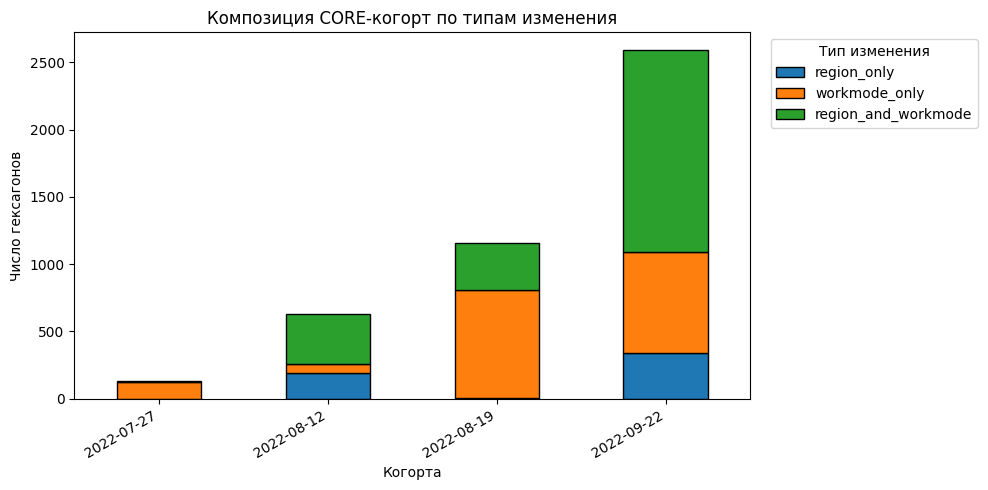

In [23]:
import matplotlib.pyplot as plt

FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)

core = report["composition_sch"][
    ["region_only", "workmode_only", "region_and_workmode"]
].copy()

core.index = pd.to_datetime(core.index).strftime("%Y-%m-%d")

ax = core.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    edgecolor="black"
)

ax.set_title("Композиция CORE-когорт по типам изменения")
ax.set_xlabel("Когорта")
ax.set_ylabel("Число гексагонов")
ax.legend(title="Тип изменения", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIG_DIR / "cohort_composition_core_counts.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "cohort_composition_core_counts.png", dpi=300, bbox_inches="tight")
plt.show()

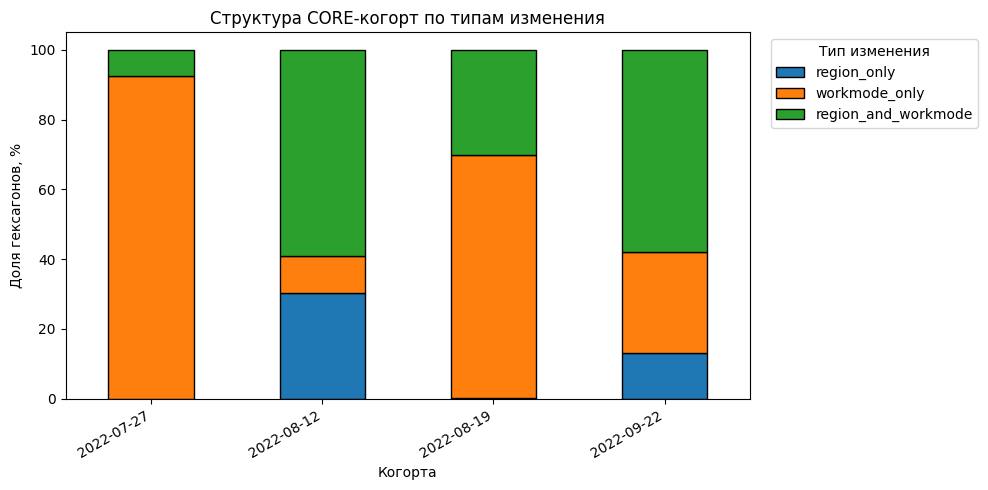

In [24]:
core_share = core.div(core.sum(axis=1), axis=0) * 100

ax = core_share.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    edgecolor="black"
)

ax.set_title("Структура CORE-когорт по типам изменения")
ax.set_xlabel("Когорта")
ax.set_ylabel("Доля гексагонов, %")
ax.legend(title="Тип изменения", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIG_DIR / "cohort_composition_core_shares.pdf", bbox_inches="tight")
plt.savefig(FIG_DIR / "cohort_composition_core_shares.png", dpi=300, bbox_inches="tight")
plt.show()

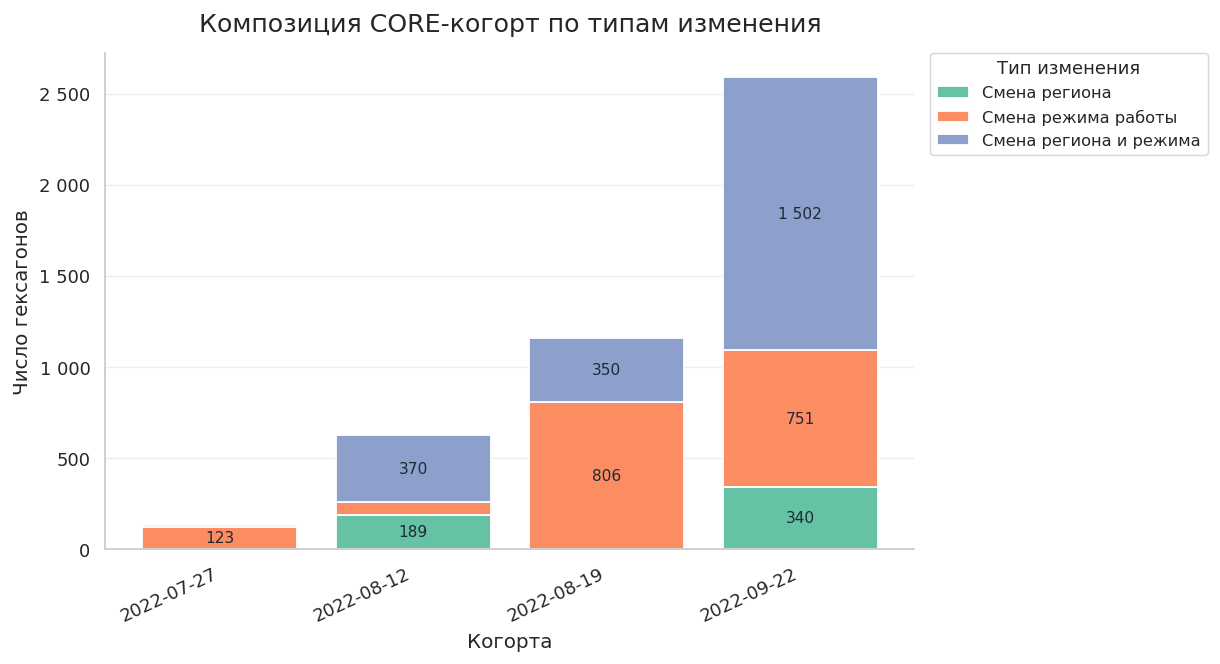

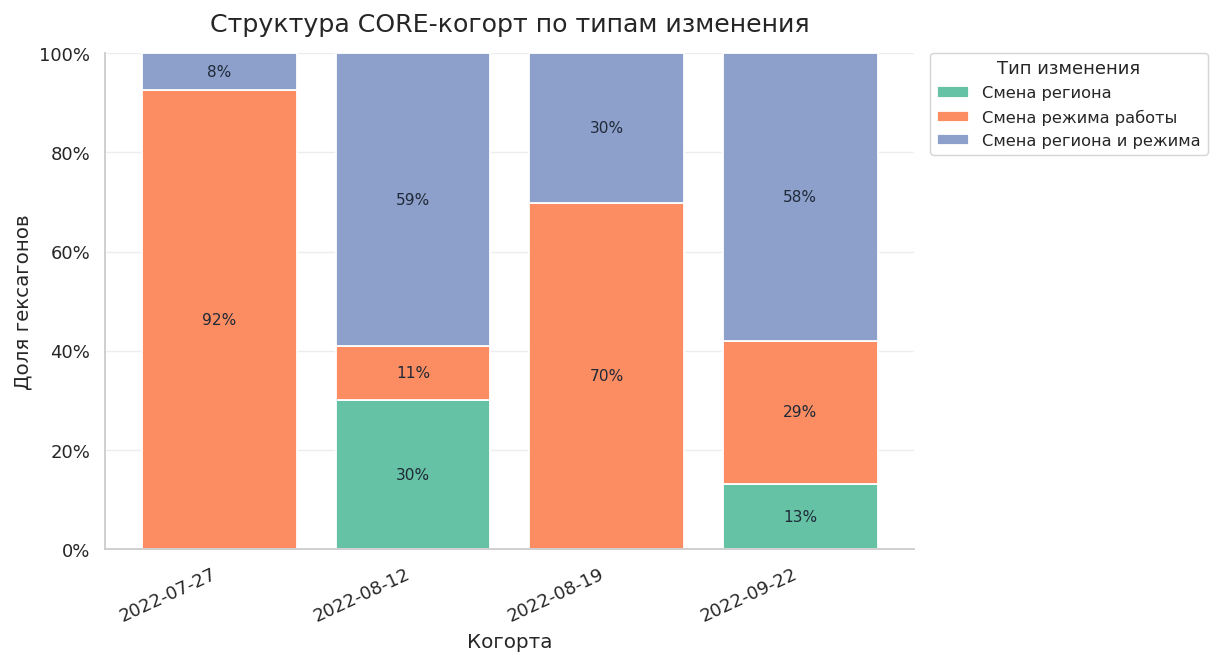

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter, FuncFormatter
from last_mile.plot_style import (
    PALETTE, TYPE_LABELS, TYPE_ORDER, save_figure, with_plot_style
)

# Папка для графиков
FIG_DIR = PROJECT_ROOT / "figures" / "empirical"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Стиль
sns.set_theme(
    context="paper",
    style="whitegrid",
    font="DejaVu Sans",
    rc={
        "figure.dpi": 130,
        "savefig.dpi": 300,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
    }
)

colors = {change_type: PALETTE[change_type] for change_type in TYPE_ORDER}

# Таблица CORE-состава
core = report["composition_sch"][TYPE_ORDER].copy()
core.index = pd.to_datetime(core.index).strftime("%Y-%m-%d")


@with_plot_style
def plot_stacked_counts(df, filename):
    fig, ax = plt.subplots(figsize=(9.5, 5.2))

    x = np.arange(len(df.index))
    bottom = np.zeros(len(df))

    for col in TYPE_ORDER:
        values = df[col].values
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            label=TYPE_LABELS[col],
            color=colors[col],
            edgecolor="white",
            linewidth=1.0,
        )

        # Подписи внутри крупных сегментов
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val >= 80:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + val / 2,
                    f"{int(val):,}".replace(",", " "),
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    color="#1F2937",
                )

        bottom += values

    ax.set_title("Композиция CORE-когорт по типам изменения", pad=12)
    ax.set_xlabel("Когорта")
    ax.set_ylabel("Число гексагонов")
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, rotation=25, ha="right")

    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
    )

    ax.legend(
        title="Тип изменения",
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax, left=False, bottom=False)

    fig.tight_layout()
    save_figure(fig, FIG_DIR / f"{filename}.pdf", preview_png=True, preview_dpi=240)


@with_plot_style
def plot_stacked_shares(df, filename):
    shares = df.div(df.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(9.5, 5.2))

    x = np.arange(len(shares.index))
    bottom = np.zeros(len(shares))

    for col in TYPE_ORDER:
        values = shares[col].values
        bars = ax.bar(
            x,
            values,
            bottom=bottom,
            label=TYPE_LABELS[col],
            color=colors[col],
            edgecolor="white",
            linewidth=1.0,
        )

        # Подписи долей внутри сегментов
        for i, (bar, val) in enumerate(zip(bars, values)):
            if val >= 7:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + val / 2,
                    f"{val:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8.5,
                    color="#1F2937",
                )

        bottom += values

    ax.set_title("Структура CORE-когорт по типам изменения", pad=12)
    ax.set_xlabel("Когорта")
    ax.set_ylabel("Доля гексагонов")
    ax.set_xticks(x)
    ax.set_xticklabels(shares.index, rotation=25, ha="right")
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

    ax.legend(
        title="Тип изменения",
        frameon=True,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", visible=False)
    sns.despine(ax=ax, left=False, bottom=False)

    fig.tight_layout()
    save_figure(fig, FIG_DIR / f"{filename}.pdf", preview_png=True, preview_dpi=240)


plot_stacked_counts(core, "cohort_composition_core_counts")
plot_stacked_shares(core, "cohort_composition_core_shares")

## Вывод

После предоценочной диагностики состава когорт было установлено, что формальная группа воздействия неоднородна и не должна напрямую использоваться как единая интерпретируемая группа воздействия. После фильтров пайплайна в группе воздействия находится `9 328` гексагонов, однако только `4 510` из них относятся к CORE-типам изменений: `region_only`, `workmode_only`, `region_and_workmode`. Остальная часть группы воздействия состоит из non-CORE случаев (`other`, `opened`, `closed`, `never_active`), которые имеют иную содержательную интерпретацию.

Для основной оценки по `sch_flg` используется CORE-выборка из четырёх когорт: `2022-07-27`, `2022-08-12`, `2022-08-19` и `2022-09-22`. В ней остаётся `4 510` CORE-гексагонов. Для `success_flg` и `utlz_flg` дополнительно исключается когорта `2022-07-27`, поскольку ранее по ней было выявлено нарушение предпосылки параллельных трендов для конверсионных исходов. Поэтому для конверсий используется более узкая CORE-выборка из `4 377` гексагонов.

Главным методологическим ограничением является композиционная гетерогенность когорт. Когорты различаются не только датой воздействия, но и типом изменения логистической конфигурации: например, `2022-08-19` преимущественно состоит из `workmode_only`, тогда как `2022-08-12` и `2022-09-22` в основном представлены `region_and_workmode`. Следовательно, сравнение ранних и поздних когорт частично смешивает эффект времени воздействия с эффектом типа воздействия.

Поэтому результаты событийной модели следует интерпретировать как эффект изменений логистической конфигурации в CORE-выборке воздействия, а не как полностью однородный эффект одного и того же типа воздействия. Если в работе обсуждается когортная гетерогенность эффектов, необходимо явно оговорить, что она может отражать различия в составе `change_type`. Более строгая проверка — дополнительно оценивать эффекты отдельно по типам CORE-изменений или включать стратификацию по `change_type`.
